In [2]:
import mne 
from nilearn import datasets
import nibabel
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
from mne.simulation import add_noise


In [3]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
mne.datasets.fetch_aparc_sub_parcellation(subjects_dir=fs_dir)

0 files missing from root.txt in C:\Users\hugop\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage


In [4]:
subjects_dir = Path(fs_dir).parent
subjects_dir

WindowsPath('C:/Users/hugop/mne_data/MNE-fsaverage-data')

In [5]:
subject='fsaverage'

In [6]:
model = mne.make_bem_model(subject = subject, subjects_dir = subjects_dir)
bem = mne.make_bem_solution(model)

Creating the BEM geometry...
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
outer skin  CM is  -0.21 -19.38  -0.23 mm
outer skull CM is  -0.19 -19.34  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is approximately    5.4 mm
Surfaces passed the basic topology checks.
Complete.

Three-layer model surfaces loaded.
Computing the linear collocation solution...
    Matrix coefficients...
     

In [7]:
labels = mne.read_labels_from_annot(
    subject=subject,
    parc='aparc',
    subjects_dir=subjects_dir
)
len(labels)

Reading labels from parcellation...
   read 35 labels from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.annot


69

In [8]:
for l in labels :
    print(l.name)

bankssts-lh
bankssts-rh
caudalanteriorcingulate-lh
caudalanteriorcingulate-rh
caudalmiddlefrontal-lh
caudalmiddlefrontal-rh
cuneus-lh
cuneus-rh
entorhinal-lh
entorhinal-rh
frontalpole-lh
frontalpole-rh
fusiform-lh
fusiform-rh
inferiorparietal-lh
inferiorparietal-rh
inferiortemporal-lh
inferiortemporal-rh
insula-lh
insula-rh
isthmuscingulate-lh
isthmuscingulate-rh
lateraloccipital-lh
lateraloccipital-rh
lateralorbitofrontal-lh
lateralorbitofrontal-rh
lingual-lh
lingual-rh
medialorbitofrontal-lh
medialorbitofrontal-rh
middletemporal-lh
middletemporal-rh
paracentral-lh
paracentral-rh
parahippocampal-lh
parahippocampal-rh
parsopercularis-lh
parsopercularis-rh
parsorbitalis-lh
parsorbitalis-rh
parstriangularis-lh
parstriangularis-rh
pericalcarine-lh
pericalcarine-rh
postcentral-lh
postcentral-rh
posteriorcingulate-lh
posteriorcingulate-rh
precentral-lh
precentral-rh
precuneus-lh
precuneus-rh
rostralanteriorcingulate-lh
rostralanteriorcingulate-rh
rostralmiddlefrontal-lh
rostralmiddlefrontal

In [9]:
temp_regions = []
for l in labels:
    if 'temp' in l.name:
        temp_regions.append(l)
        # print(l)

temp_regions_supp = []
for l in labels:
    if 'marginal' in l.name:
        temp_regions_supp.append(l)
        # print(l)
        
lexico_seman = temp_regions[:4]
# lexico_phono1 = temp_regions[4:8] # sans transversetemporal
lexico_phono2 = temp_regions_supp
lexico_phono1 = temp_regions[4:] # avec temptransversal

lexico_phono1.extend(lexico_phono2)
lexico_phono = lexico_phono1

In [10]:
occ_regions = []
for l in labels:
    if 'occ' in l.name or 'fusi' in l.name or 'pericalca' in l.name or 'cuneus-rh' == l.name or 'cuneus-lh' == l.name:
        occ_regions.append(l)
        print(l)

Visuel_conceptuel = occ_regions

<Label | fsaverage, 'cuneus-lh', lh : 1630 vertices>
<Label | fsaverage, 'cuneus-rh', rh : 1638 vertices>
<Label | fsaverage, 'fusiform-lh', lh : 4714 vertices>
<Label | fsaverage, 'fusiform-rh', rh : 4661 vertices>
<Label | fsaverage, 'lateraloccipital-lh', lh : 6379 vertices>
<Label | fsaverage, 'lateraloccipital-rh', rh : 5963 vertices>
<Label | fsaverage, 'pericalcarine-lh', lh : 1912 vertices>
<Label | fsaverage, 'pericalcarine-rh', rh : 1823 vertices>


In [11]:
broca_region = []
for l in labels :
    if 'opercularis' in l.name or 'precentral' in l.name or 'triangularis' in l.name : #or 'pars' in l.name:
        broca_region.append(l)
        print(l)

phono = broca_region
# phono = broca_region[:2]

<Label | fsaverage, 'parsopercularis-lh', lh : 3119 vertices>
<Label | fsaverage, 'parsopercularis-rh', rh : 2472 vertices>
<Label | fsaverage, 'parstriangularis-lh', lh : 2046 vertices>
<Label | fsaverage, 'parstriangularis-rh', rh : 2380 vertices>
<Label | fsaverage, 'precentral-lh', lh : 10740 vertices>
<Label | fsaverage, 'precentral-rh', rh : 10705 vertices>


In [12]:
region_motrice = []
for l in labels :
    if 'postcentral' in l.name or 'insula' in l.name or 'precentral' in l.name:
        region_motrice.append(l)
        print(l)

# articulation = region_motrice[:4] # sans precentral
articulation = region_motrice # avec precentral


<Label | fsaverage, 'insula-lh', lh : 5229 vertices>
<Label | fsaverage, 'insula-rh', rh : 5090 vertices>
<Label | fsaverage, 'postcentral-lh', lh : 9519 vertices>
<Label | fsaverage, 'postcentral-rh', rh : 9138 vertices>
<Label | fsaverage, 'precentral-lh', lh : 10740 vertices>
<Label | fsaverage, 'precentral-rh', rh : 10705 vertices>


In [13]:
region_bruit = []
for l in labels :
    if 'frontal' in l.name or 'Pars' in l.name:
        region_bruit.append(l)
        print(l)

bruit1 = region_bruit[:4]
bruit2 = region_bruit[6:]

bruit1.extend(bruit2)
bruit = bruit1

<Label | fsaverage, 'caudalmiddlefrontal-lh', lh : 3736 vertices>
<Label | fsaverage, 'caudalmiddlefrontal-rh', rh : 3494 vertices>
<Label | fsaverage, 'frontalpole-lh', lh : 272 vertices>
<Label | fsaverage, 'frontalpole-rh', rh : 369 vertices>
<Label | fsaverage, 'lateralorbitofrontal-lh', lh : 4188 vertices>
<Label | fsaverage, 'lateralorbitofrontal-rh', rh : 4354 vertices>
<Label | fsaverage, 'medialorbitofrontal-lh', lh : 2653 vertices>
<Label | fsaverage, 'medialorbitofrontal-rh', rh : 2801 vertices>
<Label | fsaverage, 'rostralmiddlefrontal-lh', lh : 7243 vertices>
<Label | fsaverage, 'rostralmiddlefrontal-rh', rh : 7864 vertices>
<Label | fsaverage, 'superiorfrontal-lh', lh : 12179 vertices>
<Label | fsaverage, 'superiorfrontal-rh', rh : 11878 vertices>


In [14]:
dico_fonction = {
    'visuo_conceptuel' : Visuel_conceptuel,
    'lexico_semantique' : lexico_seman,
    'lexico_phonologique' : lexico_phono,
    'phonologique' : phono,
    'articulation' : articulation,
    'bruit' : bruit,
}

In [15]:
src = mne.setup_source_space(
    subject=subject,
    spacing='ico5',
    subjects_dir=subjects_dir,
    add_dist=False
)


Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\hugop\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 5

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (5) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 10242/163842 selected to source space (ico = 5)

Loading C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (5) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 10242/163842 selected to 

In [16]:
hemi = 0 # 0 = left | 1 = right


rr = src[hemi]['rr']
vertno = src[hemi]['vertno'] 
coords = rr[vertno] 

In [17]:
# atlas = {
#     "frontal": frontal_vertices,
#     "parietal": parietal_vertices,
#     "occipital": occipital_vertices,
#     "temporal": temporal_vertices,
    
#     # "temporal_ant": temp_ant,
#     # "temporal_post": temp_post,
#     # "temporal_sup": temp_sup,
#     # "temporal_inf": temp_inf,
# }

In [18]:
sfreq = 512
time = np.linspace(0,1,sfreq)
# signal[len(time)//2:len(time)//2+len(time)//4] = 1


In [19]:
dico_vertice = {}
for key, value in dico_fonction.items():
    dico_vertice[key] = {
        "lh" : [],
        "rh" : [],
    }
    for sous_region in value :
        if sous_region.hemi == 'lh' :
            dico_vertice[key]["lh"].append(sous_region.vertices)
        elif sous_region.hemi == 'rh' :
            dico_vertice[key]["rh"].append(sous_region.vertices)

    dico_vertice[key]["lh"] = np.concatenate(dico_vertice[key]["lh"])
    dico_vertice[key]["rh"] = np.concatenate(dico_vertice[key]["rh"])


# for r in articulation:       # changer la fonction a afficher
#     if r.hemi == 'lh':
#         vertice_lh.append(r.vertices)
        
#     elif r.hemi == 'rh':
#         vertice_rh.append(r.vertices)

# vertice_lh = np.concatenate(vertice_lh)
# vertice_rh = np.concatenate(vertice_rh)

# print(f"avant : len lh = {len(vertice_lh)} | len rh = {len(vertice_rh)}")

# vertice_lh = np.unique(vertice_lh)
# vertice_rh = np.unique(vertice_rh)

# print(f"apres : len lh = {len(vertice_lh)} | len rh = {len(vertice_rh)}")

# vertice_lh

dico_vertice 

{'visuo_conceptuel': {'lh': array([   139,    300,    301, ..., 162651, 162652, 162653],
        shape=(14635,)),
  'rh': array([   132,    285,    286, ..., 161915, 161916, 161917],
        shape=(14085,))},
 'lexico_semantique': {'lh': array([   152,    153,    154, ..., 161932, 161933, 161980], shape=(8867,)),
  'rh': array([    11,    150,    158, ..., 163735, 163736, 163737], shape=(9255,))},
 'lexico_phonologique': {'lh': array([    10,     28,     29, ..., 156287, 156288, 156297],
        shape=(17774,)),
  'rh': array([    36,     38,     78, ..., 159863, 159864, 159865],
        shape=(16616,))},
 'phonologique': {'lh': array([    26,     61,     93, ..., 154433, 154434, 154435],
        shape=(15905,)),
  'rh': array([    21,     53,    112, ..., 153521, 153522, 153523],
        shape=(15557,))},
 'articulation': {'lh': array([    27,     60,     80, ..., 154433, 154434, 154435],
        shape=(25488,)),
  'rh': array([     8,     77,    113, ..., 153521, 153522, 153523],
   

In [20]:
class Signal_source():

    def __init__(self, src, cog_function = None, limit_time_window = None, sfreq = 512):
        """ 
        cog_function is a list of all our "cognitive funcition" or "stage" before the word production 
        ex : ['function_a', 'function_b', (...)] --> type(str)
        limit_time_window is a list of tuple representing the time window (in ms) of each cognitive function : the first time window to the first cognitive function... 
        ex : [(100,200), (200,275),(...)] --> type(tuple of int)
        src is the source space that we use to simulate the data
        """

        self.sfreq = sfreq
        self.cog_founction = cog_function
        self.limit_time_window = limit_time_window
        self.source_space = src

        self.time_global = self.set_time_global()
        self.time_window = self.set_time_window()
        self.time_start_gap = self.set_time_start_gap()

        self.signal_start_gap  = self.init_signal()[0]          # dico[cog_funct] signal between 0 and first simulation
        self.signal_sequence = self.init_signal()[1]            # dico[cog_fuct][time_window] signal between time_window[0] and time_window[1]
        self.signal_global = self.init_signal()[2]              # dico[cog_funct] all the signal of one cognitive function

        self.data = None

    def compute_time_global(self) :
        """ 
        TOOL : creation of the global time window
        """  
        start = 0
        end = self.limit_time_window[len(self.limit_time_window)-1][1]

        nb_pts = (end - start) * self.sfreq / 1000 
        return np.linspace(start,end,int(nb_pts)+1)
    
    def set_time_global(self):

        out = self.compute_time_global()
        self.time_global = out
        return out
    

    def compute_time_window(self,start,end) :
        """ 
        TOOL : creation of sub-window in the global time window
        """
        time = self.time_global
        return time[(time >= start) & (time < end)]
        

    def set_time_start_gap(self):

        out = self.compute_time_window(start = 0,end = self.limit_time_window[0][0])
        self.time_start_gap = out
        return out


    def set_time_window(self):

        dico_out = {}
        for start, end in self.limit_time_window:
            dico_out[(start,end)] = self.compute_time_window(start,end)

        self.time_window = dico_out
        
        return dico_out


    def init_signal(self) :
        dico_out_seq = {}
        dico_out_global = {}
        dico_out_start_gap = {}

        for cf in self.cog_founction:
            dico_out_seq[cf] = {}
            dico_out_global[cf] = np.zeros(len(self.time_global))
            dico_out_start_gap[cf] = np.zeros(len(self.time_start_gap))
            for tw in self.time_window :
                start, end = tw
                dico_out_seq[cf][tw] = np.zeros(len(self.time_window[(start,end)]))
        self.signal_sequence = dico_out_seq
        self.signal_global = dico_out_global
        self.signal_start_gap = dico_out_start_gap
        return dico_out_start_gap, dico_out_seq, dico_out_global
    
    def reset_signal(self, function):
        self.signal_global[function] = 0


    def set_cog_function(self,liste_cog_function):
        self.cog_founction = liste_cog_function
    
    def set_limit_time_window(self,limit_time_window):
        self.limit_time_window = limit_time_window
    
    def update_signal_from_global(self):
        
        for cf in self.cog_founction:
            gap = len(self.signal_start_gap[cf])
            self.signal_start_gap[cf] = self.signal_global[cf][:gap]
 
            for tw in self.time_window :
                i_start = gap
                gap += len(self.time_window[(tw[0],tw[1])])
                i_end = gap
                self.signal_sequence[cf][(tw[0],tw[1])] = self.signal_global[cf][i_start:i_end]


    # def update_signal_from_sequence(self,):


    def set_gauss_to_function(self,function, mean,std, amplitude) :
        if function not in self.cog_founction:
            print(f'cognitive function {function} is not in {self.cog_founction}')

        amplitude = amplitude *8e-10 # *1e-12

        self.signal_global[function] += amplitude * np.exp(- (self.time_global - mean)**2 / (2 * std**2))
        self.update_signal_from_global()

    def set_asym_gauss_to_function(self, function, mean, std_left, std_right, amplitude):
        if function not in self.cog_founction:
            print(f'cognitive function {function} is not in {self.cog_founction}')

        amplitude = amplitude *8e-10 # * 1e-12
        self.signal_global[function] += np.where(self.time_global < mean, 
                                                 amplitude * np.exp(-((self.time_global - mean)**2) / (2 * std_left**2)),
                                                 amplitude * np.exp(-((self.time_global - mean)**2) / (2 * std_right**2)))
        self.update_signal_from_global()



    def set_signal_to_function(signal,function, all_signal = True):
        """
        signal is a mathematical function which reproduce the activation of the cerebral area (f(x) = ax + b)
        fuction is the name of the cognitive function that we want to apply th signal ('function_a')

        en cours de dev [...]
        """

        
    def set_data(self):
        """ 
        Can use this function when all the signal are set to transform these signal in data for simulation
        """
        n_lh = self.source_space[0]['nuse']
        n_rh = self.source_space[1]['nuse']
        data = np.zeros((n_lh + n_rh, len(self.time_global)))

        for cf , signal in self.signal_global.items():
            
            src_vertices = src[0]['vertno']
            inter = np.intersect1d(src_vertices, dico_vertice[cf]['lh'])
            idx = np.searchsorted(src_vertices, inter)
            data[idx, :] += signal

            src_vertices = src[1]['vertno']
            inter = np.intersect1d(src_vertices, dico_vertice[cf]['rh'])
            idx = np.searchsorted(src_vertices, inter)
            data[n_lh + idx, :] += signal
        
        self.data = data
        return data

FCT = list(dico_vertice.keys())



# for cf in test.cog_founction:
#     for tw_key, tw_time in test.time_window.items():
#         plt.plot(test.time_window[tw_key],test.signal_sequence[cf][tw_key],label= fc)
        
#     plt.title(label= f'time window of {cf}')
#     plt.show()
FCT


['visuo_conceptuel',
 'lexico_semantique',
 'lexico_phonologique',
 'phonologique',
 'articulation',
 'bruit']

Model Seriel

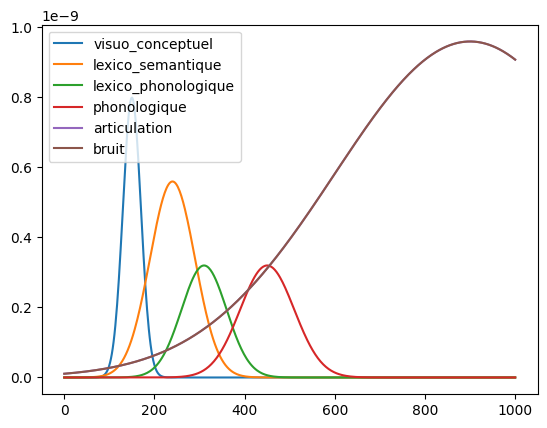

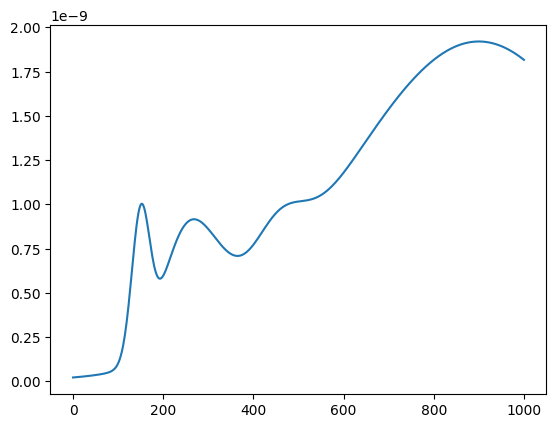

In [21]:
test = Signal_source(src=src,cog_function=FCT,limit_time_window=[(100,200),(200,275),(275,350),(350,600),(600,1000),(600,1000)])
# for fc in FCT
test.set_gauss_to_function(function=FCT[0],mean = 150,std = 20,amplitude=1)
# test.set_gauss_to_function(function=FCT[0],mean = 150,std = 20,amplitude=1)
# test.set_gauss_to_function(function=FCT[0],mean = 150,std = 20,amplitude=1)
test.set_gauss_to_function(function=FCT[1],mean = 240,std = 50,amplitude=0.7)
# test.set_gauss_to_function(function=FCT[1],mean = 240,std = 50,amplitude=0.87)
test.set_gauss_to_function(function=FCT[2],mean = 310,std = 50,amplitude=0.4)
test.set_gauss_to_function(function=FCT[3],mean = 450,std = 60,amplitude=0.4)
test.set_gauss_to_function(function=FCT[4],mean = 900,std = 300,amplitude=1.2)
test.set_gauss_to_function(function=FCT[5],mean = 900,std = 300,amplitude=1.2)

test.set_data()


mix = np.zeros(len(test.time_global))
for fc in test.cog_founction:
    # print(test.time_global[fc])
    plt.plot(test.time_global,test.signal_global[fc],label= fc)
    mix += test.signal_global[fc]
plt.legend()
plt.show()

plt.plot(test.time_global,mix,label = "signal entier")
plt.show()


Model cascade

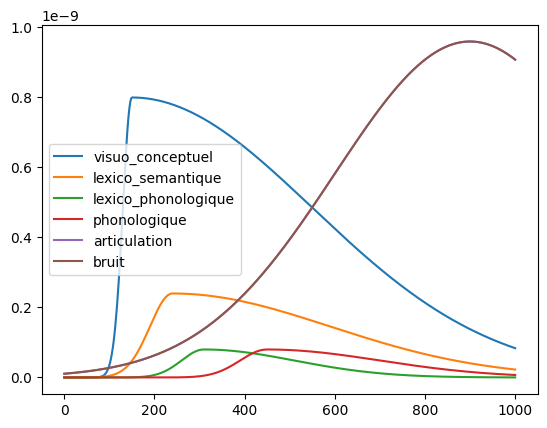

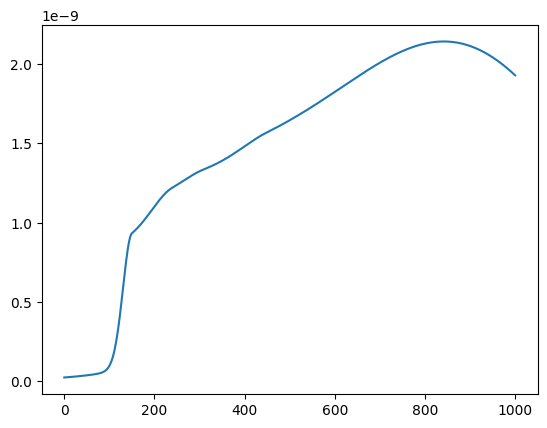

In [22]:
test2 = Signal_source(src=src,cog_function=FCT,limit_time_window=[(100,200),(200,275),(275,350),(350,600),(600,1000),(600,1000)])

test2.set_asym_gauss_to_function(function = FCT[0], mean = 150,std_left = 20, std_right=400, amplitude = 1)
test2.set_asym_gauss_to_function(function = FCT[1], mean = 240,std_left = 50, std_right=350, amplitude = 0.3)
test2.set_asym_gauss_to_function(function = FCT[2], mean = 310,std_left = 50, std_right=200, amplitude = 0.1)
test2.set_asym_gauss_to_function(function = FCT[3], mean = 450,std_left = 60, std_right=250, amplitude = 0.1)
# test2.set_asym_gauss_to_function(function = FCT[4], mean = 750,std_left = 200, std_right=200, amplitude = 10)
test2.set_gauss_to_function(function=FCT[4],mean = 900,std = 300,amplitude=1.2)
test2.set_gauss_to_function(function=FCT[5],mean = 900,std = 300,amplitude=1.2)
test2.set_data()

mix = np.zeros(len(test2.time_global))
for fc in test2.cog_founction:
    # print(test.time_global[fc])
    plt.plot(test2.time_global,test2.signal_global[fc],label= fc)
    mix += test2.signal_global[fc]
plt.legend()
plt.show()

plt.plot(test2.time_global,mix,label = "signal entier")
plt.show()

In [23]:
FCT

['visuo_conceptuel',
 'lexico_semantique',
 'lexico_phonologique',
 'phonologique',
 'articulation',
 'bruit']

Model parallelle

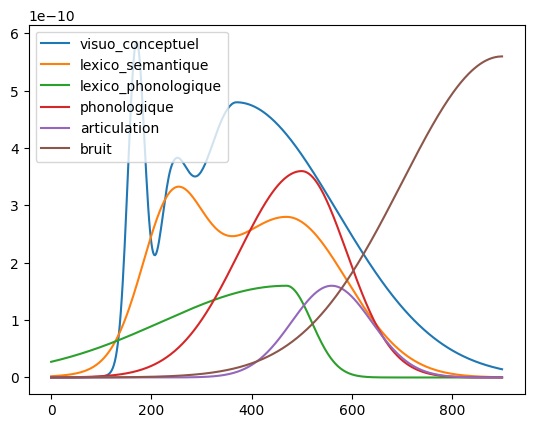

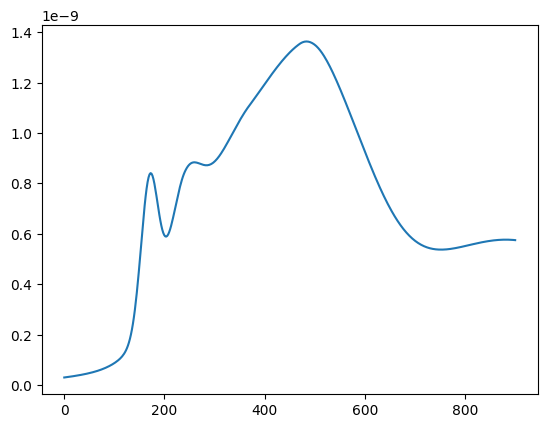

[1.91274920e-12 2.16251000e-12 2.47667340e-12 2.88028996e-12
 3.40784005e-12 4.10603419e-12 5.03708348e-12 6.28236394e-12
 7.94631527e-12 1.01603124e-11 1.30861301e-11 1.69184977e-11
 2.18861276e-11 2.82505179e-11 3.63017967e-11 4.63509276e-11
 5.87177384e-11 7.37145037e-11 9.16251891e-11 1.12680952e-10
 1.37033054e-10 1.64724898e-10 1.95665451e-10 2.29606649e-10
 2.66127603e-10 3.04628255e-10 3.44334712e-10 3.84317726e-10
 4.23524668e-10 4.60824159e-10 4.95061119e-10 5.25118793e-10
 5.49983307e-10 5.68805702e-10 5.80956294e-10 5.86066667e-10
 5.84055535e-10 5.75136130e-10 5.59804410e-10 5.38809131e-10
 5.13106431e-10 4.83802900e-10 4.52091947e-10 4.19188630e-10
 3.86267877e-10 3.54410372e-10 3.24559297e-10 2.97489889e-10
 2.73792412e-10 2.53867988e-10 2.37935666e-10]
[2.26048483e-10 2.18115853e-10 2.13929588e-10 2.13191104e-10
 2.15537720e-10 2.20566546e-10 2.27854973e-10 2.36977324e-10
 2.47517659e-10 2.59079070e-10 2.71289988e-10 2.83808145e-10
 2.96322838e-10 3.08556041e-10 3.20262

In [24]:
test3 = Signal_source(src=src,cog_function=FCT,limit_time_window=[(100,200),(200,275),(275,350),(350,600),(600,900),(600,900)])

test3.set_gauss_to_function(function = FCT[0], mean = 170,std = 17, amplitude = 0.7)
# test3.set_gauss_to_function(function = FCT[0], mean = 220,std = 20, amplitude = 0.5)
test3.set_asym_gauss_to_function(function = FCT[0], mean = 240, std_left = 25,std_right= 30,amplitude = 0.3)

test3.set_asym_gauss_to_function(function = FCT[0], mean = 370, std_left =80,std_right= 200,amplitude = 0.6)

# test3.set_gauss_to_function(function = FCT[1], mean = 150,std = 20, amplitude = 0.3)
test3.set_gauss_to_function(function = FCT[1], mean = 240,std = 60, amplitude = 0.3)
test3.set_asym_gauss_to_function(function = FCT[1], mean = 470, std_left = 150,std_right= 120,amplitude = 0.35)

# test3.set_asym_gauss_to_function(function = FCT[1], mean = 300,std_left = 50, std_right=200, amplitude = 0.7)

# test3.set_gauss_to_function(function = FCT[2], mean = 380,std = 50, amplitude = 0.3)
test3.set_asym_gauss_to_function(function = FCT[2], mean = 470,std_left = 250,std_right = 50, amplitude = 0.2)

test3.set_asym_gauss_to_function(function = FCT[3], mean = 500,std_left = 125, std_right = 90, amplitude = 0.45)
# test3.set_gauss_to_function(function = FCT[3], mean = 380,std = 150, amplitude = 0.6)

# test3.set_asym_gauss_to_function(function = FCT[4], mean = 900, std_left = 200,std_right= 50,amplitude = 1)

test3.set_gauss_to_function(function=FCT[4],mean = 560,std = 80,amplitude=0.2)
test3.set_gauss_to_function(function=FCT[5],mean = 900,std = 200,amplitude=0.7)
test3.set_data()

mix = np.zeros(len(test3.time_global))
for fc in test3.cog_founction:
    # print(test3.time_global[fc])
    plt.plot(test3.time_global,test3.signal_global[fc],label= fc)
    mix += test3.signal_global[fc]
plt.legend()
plt.show()

plt.plot(test3.time_global,mix,label = "signal entier")
plt.show()


fc = test3.cog_founction[0]
for el in test3.signal_sequence[fc]:
    print(test3.signal_sequence[fc][el])
print(test3.signal_sequence[fc])

print(FCT)

In [25]:


def make_simulation(Signal_source_obj, viz_simulation = False, save_movie = False, add_noise = False):
    """
    To run, it's necessary to process the BEM folder before with : 
    
    model = mne.make_bem_model(subject = subject, subjects_dir = subjects_dir)
    bem = mne.make_bem_solution(model)

    """
    montage = mne.channels.make_standard_montage('biosemi128')
    info = mne.create_info(sfreq = 512, ch_names = montage.ch_names,ch_types = 'eeg')
    info.set_montage(montage)

    def motor(obj, info = info, viz_simulation = viz_simulation, save_movie = save_movie):

        # def viz_simulation(obj = obj, save = save_movie):

        #     os.environ["QT_API"] = "pyqt5"
        #     mne.viz.set_3d_backend("pyvista")

        #     return stc.plot(subjects_dir=subjects_dir,hemi = 'both', clim='auto')




        stc = mne.SourceEstimate(
            obj.data,
            vertices=[src[0]['vertno'], src[1]['vertno']],
            tmin=0,
            tstep=1/sfreq,
            subject=subject)
        
        # if viz_simulation : 
        #     video = viz_simulation(obj)
        # #     if save_movie :
        # #         video.save_movie(filename= "simulation_model_caricature_1.mp4", time_dilation=1,framerate = 30)

        fwd = mne.make_forward_solution(
            info,
            trans='fsaverage',
            src= src,
            bem= str(fs_dir) + r'/bem/fsaverage-5120-5120-5120-bem-sol.fif',
            eeg=True,
            mindist=5.0,
            n_jobs=1
        )

        raw = mne.simulation.simulate_raw(
            info,
            stc,
            forward=fwd
        )
        
        if add_noise :
            cov = mne.make_ad_hoc_cov(info)
            add_noise(raw, cov)
            return raw
        else :  
            return raw

    if type(Signal_source_obj) == list :
        list_out = []
        for ss_obj in Signal_source_obj:
            list_out.append(motor(ss_obj))
        return list_out
    else :
        list_out = []
        list_out.append(motor(Signal_source_obj))
        return list_out

In [26]:
def viz_raw(liste,size_window = None, label = None , movie = False, save = False):

    """ 
    liste           is a list of raw signal simulated by make_simulation()
    size_window     is in centimeter
    label           is the list of title you want on each plot

    """
    if label is None :
        label = ["No label"] * len(liste)
    
    if type(size_window) is int:
        size_window = list(size_window) * len(liste)

    liste_evoked = []
    for raw, l, sz in zip(liste, label, size_window) :
        
        epochs = mne.make_fixed_length_epochs(raw, duration=sz, preload=True)
        evoked = epochs.average()
        evoked.plot(titles=  l)
        plt.show()

viz model 1

In [27]:
# liste_signal = make_simulation(test)
# viz_raw(liste_signal,[0.8],["seriel"])

viz model 2

In [28]:
# liste_signal2 = make_simulation(test2)
# viz_raw(liste_signal2,[0.8],["cascade"])

viz model 3

Source space          : <SourceSpaces: [<surface (lh), n_vertices=163842, n_used=10242>, <surface (rh), n_vertices=163842, n_used=10242>] MRI (surface RAS) coords, subject 'fsaverage', ~25.6 MiB>
MRI -> head transform : c:\Users\hugop\Desktop\Code_Iconic\IconicEnv\lib\site-packages\mne\data\fsaverage\fsaverage-trans.fif
Measurement data      : instance of Info
Conductor model   : C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage/bem/fsaverage-5120-5120-5120-bem-sol.fif
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 2 source spaces a total of 20484 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999994 0.003552 0.000202      -1.76 mm
    -0.003558 0.998389 0.056626      31.09 mm
    -0.000001 -0.056626 0.998395      39.60 mm
    0.000000 0.000000 0.000000       1.00

Read 128 EEG channels from info
Head coordinate coil definitions created.
Source spaces are now in head coordinates.

Setting up the BEM

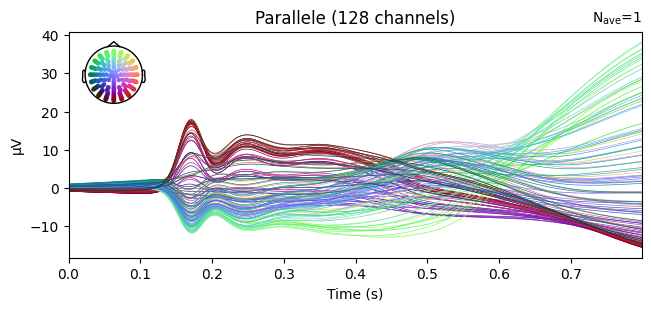

In [29]:
liste_signal3 = make_simulation(test3,add_noise = False)
viz_raw(liste_signal3,[0.8],["Parallele"])

In [30]:
# all_sig = make_simulation([test,test2,test3])
# viz_raw(all_sig,[0.8,0.8,0.8],["Seriel","Cascade","Parallele"])

In [31]:
# all_sig

Simulation d'un EEG a partir des sources

On peut aussi ajouter du bruit pour rendre la simulation plus "realiste"

In [32]:
# test_region = Signal_source(src=src,cog_function=FCT,limit_time_window=[(100,200),(200,275),(275,350),(350,600),(600,900),(600,900)])
# test_region.set_gauss_to_function(function=FCT[0],mean = 150,std = 100,amplitude=1)
# test_region.set_gauss_to_function(function=FCT[1],mean = 240,std = 100,amplitude=1)
# test_region.set_gauss_to_function(function=FCT[2],mean = 310,std = 100,amplitude=1)
# test_region.set_gauss_to_function(function=FCT[3],mean = 450,std = 100,amplitude=1)
# test_region.set_gauss_to_function(function=FCT[4],mean = 600,std = 100,amplitude=1)
# test_region.set_gauss_to_function(function=FCT[5],mean = 900,std = 100,amplitude=1)
# test_region.set_data()
# signal_region = make_simulation(test_region)
# viz_raw(signal_region,[0.8],["cascade"])
